###  **Seção 1: Otimização de Portfólio com Matriz de Covariância e Restrição de Cardinalidade**

A otimização de portfólio é problema de pesquisa operacional onde se decide **como alocar capital entre diferentes ativos financeiros**.

---

#### **Objetivo do Problema**

Queremos encontrar a melhor combinação de ativos financeiros que:

- **Maximize o retorno esperado**, considerando os pesos alocados em cada ativo;
- **Minimize o risco**, representado pela variância do portfólio com base na matriz de covariância;
- **Respeite restrições realistas**, como:
  - Selecionar no máximo **K ativos** (**restrição de cardinalidade**);
  - Impor limites de **investimento mínimo e máximo por ativo** (piso e teto);
  - Garantir que a **soma total dos pesos seja igual a 1** (100% do capital investido).

Essas restrições tornam o problema mais próximo da realidade, mas também mais complexo do ponto de vista computacional.


---

####  **Entendendo o problema e as Variáveis**

Vamos usar um exemplo com **4 ativos**:

1. **Apple (AAPL)**
2. **Google (GOOGL)**
3. **Amazon (AMZN)**
4. **Tesouro Direto (TD)** (renda fixa)

Para cada ativo nós temos :

$$
\mu_i = \text{retorno médio anual esperado do ativo } i \\
\sigma_i = \text{desvio padrão (volatilidade) do ativo } i \\
\rho_{i,j} = \text{correlação entre os ativos } i \text{ e } j \\
w_i = \text{peso (proporção do capital) investido no ativo } i
$$

Onde a soma dos pesos deve ser 100%:

$$
\sum_{i=1}^{n} w_i = 1
$$



| Ativo  | Retorno Esperado (μ) | Desvio Padrão (σ) |
|--------|-----------------------|--------------------|
| AAPL   | 0.12                  | 0.20               |
| GOOGL  | 0.10                  | 0.18               |
| AMZN   | 0.14                  | 0.25               |
| TD     | 0.05                  | 0.05               |

Correlação entre os ativos:

| Par de Ativos     | Correlação (ρ) |
|-------------------|----------------|
| AAPL & GOOGL      | 0.80           |
| AAPL & AMZN       | 0.75           |
| AAPL & TD         | 0.10           |
| GOOGL & AMZN      | 0.65           |
| GOOGL & TD        | 0.15           |
| AMZN & TD         | 0.20           |

---

####  **Passo a Passo: Construção da Matriz de Covariância**

A matriz de covariância é calculada com:

$$
\Sigma_{i,j} = \rho_{i,j} \cdot \sigma_i \cdot \sigma_j
$$

Substituindo os valores:

$$
\Sigma_{\text{AAPL, AAPL}} = 0.20^2 = 0.0400 \\
\Sigma_{\text{AAPL, GOOGL}} = 0.80 \cdot 0.20 \cdot 0.18 = 0.0288 \\
\Sigma_{\text{AAPL, AMZN}} = 0.75 \cdot 0.20 \cdot 0.25 = 0.0375 \\
\Sigma_{\text{AAPL, TD}} = 0.10 \cdot 0.20 \cdot 0.05 = 0.0010 \\
\Sigma_{\text{GOOGL, GOOGL}} = 0.18^2 = 0.0324 \\
\Sigma_{\text{GOOGL, AMZN}} = 0.65 \cdot 0.18 \cdot 0.25 = 0.02925 \\
\Sigma_{\text{GOOGL, TD}} = 0.15 \cdot 0.18 \cdot 0.05 = 0.00135 \\
\Sigma_{\text{AMZN, AMZN}} = 0.25^2 = 0.0625 \\
\Sigma_{\text{AMZN, TD}} = 0.20 \cdot 0.25 \cdot 0.05 = 0.0025 \\
\Sigma_{\text{TD, TD}} = 0.05^2 = 0.0025
$$

A matriz de covariância final será:

|         | AAPL   | GOOGL  | AMZN   | TD     |
|---------|--------|--------|--------|--------|
| **AAPL**  | 0.0400 | 0.0288 | 0.0375 | 0.0010 |
| **GOOGL** | 0.0288 | 0.0324 | 0.0293 | 0.0014 |
| **AMZN**  | 0.0375 | 0.0293 | 0.0625 | 0.0025 |
| **TD**    | 0.0010 | 0.0014 | 0.0025 | 0.0025 |

---

#### **Passo a Passo: Cálculo do Retorno Esperado**

Exemplo de alocação:

$$
w_{\text{AAPL}} = 0.3, \quad w_{\text{GOOGL}} = 0.2, \quad w_{\text{AMZN}} = 0.4, \quad w_{\text{TD}} = 0.1
$$

Com isso:

$$
E[R_p] = (0.3 \cdot 0.12) + (0.2 \cdot 0.10) + (0.4 \cdot 0.14) + (0.1 \cdot 0.05) = 0.117 \Rightarrow 11.7\%
$$

---

#### **Passo a Passo: Cálculo do Risco com a Matriz de Covariância**

$$
\sigma_p^2 = \mathbf{w}^T \cdot \Sigma \cdot \mathbf{w}
$$

Substituindo a matriz e o vetor de pesos, temos:

$$
\sigma_p^2 = 
(0.3, 0.2, 0.4, 0.1)
\begin{bmatrix}
0.0400 & 0.0288 & 0.0375 & 0.0010 \\
0.0288 & 0.0324 & 0.0293 & 0.0014 \\
0.0375 & 0.0293 & 0.0625 & 0.0025 \\
0.0010 & 0.0014 & 0.0025 & 0.0025
\end{bmatrix}
\begin{bmatrix}
0.3 \\
0.2 \\
0.4 \\
0.1
\end{bmatrix}
$$

Resultado:

$$
\sigma_p^2 \approx 0.03371 \quad \Rightarrow \quad \sigma_p \approx 18.36\%
$$

---

####  **Passo a Passo: Cálculo do Índice de Sharpe**

Assumindo taxa livre de risco \( R_f = 3\% = 0.03 \):

$$
SR = \frac{E[R_p] - R_f}{\sigma_p} = \frac{0.117 - 0.03}{0.1836} \approx 0.474
$$

---

#### **Restrição de Cardinalidade (K ativos)**

Na prática, é comum limitar o número de ativos no portfólio (ex: no máximo 10). Isso evita carteiras com muitos ativos irrelevantes.

Como o framework `CUSTOMHyS` trabalha apenas com variáveis contínuas, utilizaremos uma **heurística**:

- Geramos um vetor contínuo de pesos.
- Selecionamos os **K ativos com maiores pesos**.
- Zeros nos demais, e normalizamos os K pesos selecionados para somar 1.

---

#### **Fronteira Eficiente e Avaliação das Heurísticas**

A **Fronteira Eficiente Não Restrita (UEF)** representa todas as combinações de portfólio que **maximizam o retorno para um dado nível de risco** ou **minimizam o risco para um dado retorno**, **sem restrições de cardinalidade**.

No artigo de Chang et al. (2000), essa fronteira foi obtida por métodos exatos de otimização convexa e depois **salva em arquivos como `portef1`, `portef2` etc.** com pares 
$$
(\mu, \sigma^2)
$$
 para permitir **comparação com soluções heurísticas**.

Para avaliar a qualidade de uma solução com restrição de cardinalidade (obtida por heurística), os autores projetaram essa solução sobre a UEF. Isso foi feito por meio de interpolação linear entre os pontos da fronteira eficiente, permitindo encontrar a solução teórica mais próxima que apresenta o mesmo nível de risco ou retorno.
---

####  **O que é a Fronteira Eficiente?**

A Fronteira Eficiente é o **conjunto de portfólios ótimos**, ou seja, aqueles que:
- **Têm o menor risco possível** para um dado nível de retorno
- **Têm o maior retorno possível** para um dado nível de risco

Ela é representada graficamente por uma **curva convexa ascendente** no plano **risco × retorno**.

Imagine um gráfico com:
- Eixo X = risco (desvio padrão)
- Eixo Y = retorno esperado

A Fronteira Eficiente é a **borda superior da nuvem de pontos possíveis**, formando uma curva como essa:
#####  **Exemplo Prático**

Vamos supor que temos 1000 combinações aleatórias de portfólios feitos a partir dos ativos:
- AAPL (12%, 20%)
- GOOGL (10%, 18%)
- AMZN (14%, 25%)
- TD (5%, 5%)

Calculamos o retorno e risco de cada portfólio e traçamos todos esses pontos no plano:

$$
(\sigma, \mu)
$$

A **Fronteira Eficiente** será formada pelos **pontos mais ao norte e à esquerda** da nuvem.

Essa curva pode ser calculada resolvendo uma sequência de problemas de otimização para diferentes níveis de retorno (ou diferentes pesos):

$$
\lambda
$$

Quanto mais pontos usarmos, mais suave e precisa será a curva.

<img src=image.png alt="Fronteira Eficiente" width="45%"/>

---


####  **Métrica de Avaliação das Heurísticas**

A partir da curva UEF, os autores do artigo definiram as métricas:

- **Erro percentual na direção do risco**:

$$
\text{Erro}_{\text{risco}} = 100 \times \frac{\sigma^* - \sigma^{**}}{\sigma^{**}}
$$

- **Erro percentual na direção do retorno**:

$$
\text{Erro}_{\text{retorno}} = 100 \times \frac{\mu^* - \mu^{**}}{\mu^{**}}
$$

Onde:

$$
\begin{aligned}
(\mu^*, \sigma^*) &\text{ — solução encontrada pela heurística} \\
(\mu^{**}, \sigma^{**}) &\text{ — projeção correspondente na UEF}
\end{aligned}
$$

A **métrica final** adotada é o menor dos dois erros:

$$
\text{Erro final} = \min(\text{Erro}_{\text{risco}}, \text{Erro}_{\text{retorno}})
$$

Essa abordagem permite **comparar diretamente** o desempenho das heurísticas contra a fronteira ideal de mercado — uma métrica que é ao mesmo tempo quantitativa, interpretável e prática para aplicações científicas.

---

Essa abordagem nos permite **simular o comportamento do problema original com restrição de cardinalidade**, usando apenas variáveis contínuas. A próxima seção demonstrará isso na prática.



### 📊 **Seção 2: Resolvendo o problema com o customhys**

#### Instalando o package e baixando do github
 Utilize caso não esteja em um ambiente com o package instalado, como o google colab

In [56]:
# Clonar rep
# !git clone https://github.com/jcrvz/customhys.git .
# Instalar as dependências
# !pip install -r requirements.txt

# Instalar o CUSTOMHyS como pacote
# !pip install .
# %cd customhys
# %cd customhys

#### Função para ler instâncias OR-Library
Funções que leem instâncias que estão no formato OR-Library para o problema do portfólio single period

In [57]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt




def read_or_library_instance(filepath):
    """
    Lê um arquivo de instância da OR-Library (ex: port1.txt) e retorna:
    - número de ativos
    - retornos esperados (μ_i)
    - desvios padrão (σ_i)
    - matriz de correlação (ρ_{i,j})
    - matriz de covariância (Σ)
    - dataframe da covariância para visualização
    """

    # Abre e lê todas as linhas do arquivo
    with open(filepath, 'r') as file:
        lines = file.readlines()

    # Número total de ativos financeiros disponíveis na instância
    n_assets = int(lines[0].strip())

    # Lê os retornos esperados e os desvios padrão (μ_i e σ_i)
    returns = []
    std_devs = []
    for i in range(1, n_assets + 1):
        mu, sigma = map(float, lines[i].strip().split())
        returns.append(mu)
        std_devs.append(sigma)

    # Inicializa a matriz de correlação com 1's na diagonal principal
    corr_matrix = np.eye(n_assets)

    # Lê os pares de ativos e suas respectivas correlações ρ_{i,j}
    for line in lines[n_assets + 1:]:
        i, j, rho = line.strip().split()
        i, j = int(i) - 1, int(j) - 1  # Corrige índice (de 1-based para 0-based)
        rho = float(rho)
        corr_matrix[i][j] = rho
        corr_matrix[j][i] = rho  # Simetria da matriz

    # Constrói a matriz de covariância Σ com:
    # Σ_{i,j} = ρ_{i,j} * σ_i * σ_j
    sigma_array = np.array(std_devs)
    cov_matrix = np.outer(sigma_array, sigma_array) * corr_matrix

    # Cria um DataFrame para visualização fácil da matriz de covariância
    df_cov = pd.DataFrame(
        cov_matrix,
        columns=[f"Asset {i+1}" for i in range(n_assets)],
        index=[f"Asset {i+1}" for i in range(n_assets)]
    )

    # Retorna um dicionário com todos os dados necessários
    return {
        "n_assets": n_assets,
        "returns": np.array(returns),         # Vetor de retornos esperados μ_i
        "std_devs": np.array(std_devs),       # Vetor de desvios padrão σ_i
        "corr_matrix": corr_matrix,           # Matriz de correlação ρ_{i,j}
        "cov_matrix": cov_matrix,             # Matriz de covariância Σ
        "df_cov": df_cov                      # DataFrame para visualização
    }


In [58]:
# Lê o arquivo port1 para testar
instance_data = read_or_library_instance("port1.txt")

print("\nMatriz de Covariância\n")
display(instance_data["df_cov"].round(5))  # Arredondando para facilitar a leitura


Matriz de Covariância



,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,Asset 9,Asset 10,Asset 11,Asset 12,Asset 13,Asset 14,Asset 15,Asset 16,Asset 17,Asset 18,Asset 19,Asset 20,Asset 21,Asset 22,Asset 23,Asset 24,Asset 25,Asset 26,Asset 27,Asset 28,Asset 29,Asset 30,Asset 31
Asset 1,0.00187,0.00098,0.00133,0.00137,0.00100,0.00163,0.00137,0.00124,0.00088,0.00147,0.00115,0.00119,0.00082,0.00137,0.00085,0.00072,0.00090,0.00117,0.00119,0.00142,0.00124,0.00089,0.00133,0.00151,0.00162,0.00061,0.00140,0.00041,0.00084,0.00081,0.00082
Asset 2,0.00098,0.00162,0.00104,0.00103,0.00130,0.00113,0.00108,0.00101,0.00092,0.00107,0.00081,0.00102,0.00109,0.00114,0.00081,0.00067,0.00063,0.00103,0.00133,0.00104,0.00101,0.00083,0.00107,0.00120,0.00134,0.00064,0.00115,0.00037,0.00080,0.00079,0.00072
Asset 3,0.00133,0.00104,0.00171,0.00141,0.00097,0.00155,0.00140,0.00128,0.00111,0.00144,0.00112,0.00112,0.00087,0.00143,0.00089,0.00079,0.00082,0.00119,0.00126,0.00149,0.00129,0.00094,0.00140,0.00154,0.00169,0.00057,0.00146,0.00043,0.00092,0.00089,0.00087
Asset 4,0.00137,0.00103,0.00141,0.00202,0.00118,0.00171,0.00156,0.00144,0.00123,0.00153,0.00118,0.00136,0.00100,0.00149,0.00088,0.00084,0.00100,0.00135,0.00141,0.00180,0.00144,0.00102,0.00170,0.00182,0.00177,0.00065,0.00152,0.00049,0.00096,0.00095,0.00092
Asset 5,0.00100,0.00130,0.00097,0.00118,0.00478,0.00127,0.00121,0.00116,0.00117,0.00106,0.00070,0.00147,0.00115,0.00125,0.00084,0.00073,0.00084,0.00119,0.00225,0.00107,0.00098,0.00071,0.00130,0.00118,0.00138,0.00055,0.00130,0.00042,0.00064,0.00088,0.00063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Asset 27,0.00140,0.00115,0.00146,0.00152,0.00130,0.00174,0.00179,0.00148,0.00120,0.00165,0.00134,0.00131,0.00104,0.00156,0.00098,0.00093,0.00103,0.00139,0.00152,0.00163,0.00147,0.00110,0.00155,0.00174,0.00185,0.00078,0.00230,0.00059,0.00101,0.00101,0.00106
Asset 28,0.00041,0.00037,0.00043,0.00049,0.00042,0.00068,0.00064,0.00052,0.00048,0.00068,0.00044,0.00045,0.00042,0.00040,0.00044,0.00039,0.00050,0.00050,0.00045,0.00053,0.00048,0.00034,0.00050,0.00060,0.00062,0.00023,0.00059,0.00130,0.00048,0.00027,0.00034
Asset 29,0.00084,0.00080,0.00092,0.00096,0.00064,0.00111,0.00104,0.00101,0.00082,0.00107,0.00095,0.00089,0.00093,0.00103,0.00067,0.00067,0.00067,0.00086,0.00090,0.00108,0.00098,0.00080,0.00103,0.00123,0.00114,0.00052,0.00101,0.00048,0.00129,0.00067,0.00070
Asset 30,0.00081,0.00079,0.00089,0.00095,0.00088,0.00107,0.00099,0.00094,0.00071,0.00098,0.00092,0.00095,0.00066,0.00106,0.00076,0.00064,0.00070,0.00104,0.00104,0.00106,0.00106,0.00098,0.00093,0.00104,0.00113,0.00055,0.00101,0.00027,0.00067,0.00135,0.00088


#### Criando função de avaliação

A formulação é o **modelo de otimização de portfólio com restrição de cardinalidade** apresentado por **Chang et al. (2000)**:

---

### Função Objetivo :

$$
\min \left[ \lambda \sum_{i=1}^N \sum_{j=1}^N w_i w_j \sigma_{ij} \right] - (1 - \lambda) \left[ \sum_{i=1}^N w_i \mu_i \right]
$$

* **Objetivo:** minimizar uma combinação ponderada entre **risco** e **retorno**.
* $\lambda \in [0,1]$: parâmetro de ponderação entre risco e retorno.

  * Se $\lambda = 1$: foca 100% no risco.
  * Se $\lambda = 0$: foca 100% no retorno.
* $\sigma_{ij}$: covariância entre os ativos $i$ e $j$ → risco total do portfólio.
* $\mu_i$: retorno esperado do ativo $i$.
* $w_i$: peso do ativo $i$ na carteira.
* Essa função é equivalente a:

  $$
  \text{minimizar } \lambda \cdot \text{risco} - (1 - \lambda) \cdot \text{retorno}
  $$

---

###  Restrições

#### Soma dos pesos deve ser 1 (carteira completa):

$$
\sum_{i=1}^N w_i = 1
$$

> A soma das alocações no portfólio precisa ser 100% (normalização).

---

####  Restrição de cardinalidade:

$$
\sum_{i=1}^N z_i = K
$$

> Exige que **exatamente $K$** ativos sejam incluídos no portfólio.

* $z_i \in \{0, 1\}$: variável binária indicando se o ativo $i$ foi selecionado.

---

#### Limites mínimos e máximos de alocação por ativo:

$$
\varepsilon_i z_i \leq w_i \leq \delta_i z_i, \quad i = 1, \dots, N
$$

> Se $z_i = 1$, então $w_i$ deve estar entre $\varepsilon_i$ e $\delta_i$.
> Se $z_i = 0$, então $w_i = 0$ (ativo fora do portfólio).

---

#### Definição da variável binária:

$$
z_i \in \{0, 1\}, \quad i = 1, \dots, N
$$

> Garante que a variável $z_i$ seja binária (selecionado ou não).


In [59]:

# Lista global para registrar os resultados de cada avaliação da função
execution_logs = []

def portfolio_evaluation(
    weights, 
    instance_data, 
    k=None,                 
    lambda_=0.5, 
    risk_free_rate=0.03,
    epsilon=None,
    delta=None
):
    """
    Avalia um portfólio usando uma abordagem híbrida.
    - Se k for None, otimiza sem restrição de cardinalidade (usando todos os ativos).
    - Se epsilon/delta forem None, usa valores padrão (sem restrições de piso/teto).
    """
    n = instance_data["n_assets"]
    returns = instance_data["returns"]
    cov = instance_data["cov_matrix"]
    weights = np.array(weights)

    # --- INICIALIZAÇÃO DOS PARÂMETROS PADRÃO ---
    if epsilon is None:
        epsilon = np.zeros(n)
    if delta is None:
        delta = np.ones(n)
    
    # Se k não for especificado, o portfólio não tem restrição de cardinalidade (k = n).
    is_constrained = k is not None and k < n
    if not is_constrained:
        k = n

    # --- 1. CÁLCULO DA PENALIDADE DE SEPARAÇÃO (APENAS PARA O CASO RESTRITO) ---
    penalidade_separacao = 0
    if is_constrained:
        COEF_PENALIDADE_SEP = 0.01 
        pesos_abs_ordenados = np.sort(np.abs(weights))[::-1]
        limiar_entrada = pesos_abs_ordenados[k-1]
        primeiro_fora = pesos_abs_ordenados[k]
        gap = limiar_entrada - primeiro_fora
        if gap < 0.1:
            penalidade_separacao = COEF_PENALIDADE_SEP / (gap + 1e-6)

    # --- INÍCIO DO ALGORITMO DE REPARO ---
    
    # Seleciona os 'k' melhores ativos. Se k=n, seleciona todos.
    selected_indices = np.argsort(weights)[-k:]
    
    selected_epsilon = epsilon[selected_indices]
    selected_delta = delta[selected_indices]
    
    if np.sum(selected_epsilon) > 1.0:
        return 1e7 + penalidade_separacao, {"error": "Portfólio inviável: soma dos pisos > 1"} 

    final_k_weights = selected_epsilon.copy()
    free_assets_map = list(range(k)) 
    
    while True:
        free_capital = 1.0 - np.sum(final_k_weights)
        if free_capital < 1e-9: break
        
        s_i_free = weights[selected_indices[free_assets_map]]
        sum_s_i_free = np.sum(s_i_free)
        if sum_s_i_free > 1e-9:
            distribution = free_capital * (s_i_free / sum_s_i_free)
            final_k_weights[free_assets_map] += distribution
        
        violating_assets_map = [idx for idx in free_assets_map if final_k_weights[idx] > selected_delta[idx]]
        
        if not violating_assets_map:
            break
        else:
            for idx in violating_assets_map:
                final_k_weights[idx] = selected_delta[idx]
                free_assets_map.remove(idx)
    
    final_weights = np.zeros(n)
    final_weights[selected_indices] = final_k_weights

    # --- FIM DO ALGORITMO DE REPARO ---

    # --- AVALIAÇÃO E RETORNO ---
    expected_return = np.dot(final_weights, returns)
    variance = np.dot(final_weights, np.dot(cov, final_weights))
    
    portfolio_objective = lambda_ * variance - (1 - lambda_) * expected_return
    final_objective = portfolio_objective + penalidade_separacao
    
    risk = np.sqrt(variance)
    sharpe = (expected_return - risk_free_rate) / risk if risk > 0 else -1e6
    execution_log = {
        "execution_number": len(execution_logs) + 1,
        "weights": final_weights.copy(),
        "selected_assets": selected_indices.tolist(),
        "expected_return": expected_return,
        "risk": risk,
        "sharpe": sharpe,
        "separation_penalty": penalidade_separacao,
        "final_objective": final_objective
    }
    execution_logs.append(execution_log)

    return final_objective, execution_log

##### Testando no portifólio de 4 ativos

In [60]:

# Exemplo de teste rápido
from_port1 = {
    "n_assets": 4,
    "returns": np.array([0.12, 0.10, 0.14, 0.05]),
    "cov_matrix": np.array([
        [0.0400, 0.0288, 0.0375, 0.0010],
        [0.0288, 0.0324, 0.0293, 0.0014],
        [0.0375, 0.0293, 0.0625, 0.0025],
        [0.0010, 0.0014, 0.0025, 0.0025]
    ])
}

# Executa a função
resultado, log = portfolio_evaluation([0.45, 0.2, 0.4, 0.1], from_port1,  risk_free_rate=0.03)

# Visualiza
df_log = pd.DataFrame([log])
display(df_log[["execution_number","weights", "selected_assets", "expected_return", "risk", "sharpe"]].round(5))

,execution_number,weights,selected_assets,expected_return,risk,sharpe
0,1,"[0.3913043478260869, 0.17391304347826086, 0.34...","[3, 1, 2, 0]",0.11739,0.18061,0.48387


#### Função para criar problema no formato que a hyperheuristica aceita, utilizando os probelmas já definidos acima

In [61]:
def configure_problem(instance_data, lambda_= 0.5,risk_free_rate=0.03, epsilon=None, delta=None, k=None):
    """
    Configura o problema no formato aceito pelo CUSTOMHyS.
    
    Parâmetros:
    - instance_data: dicionário retornado por read_or_library_instance()
    - k: restrição de cardinalidade (número máximo de ativos)
    - risk_free_rate: taxa livre de risco

    Retorna:
    - dicionário com as chaves esperadas por CUSTOMHyS
    """
    n = instance_data["n_assets"]
    lower_bounds = [0.00] * n
    upper_bounds = [1.00] * n
    return {
        "function": lambda weights: portfolio_evaluation(weights, instance_data, lambda_=lambda_, risk_free_rate=risk_free_rate, k = k, epsilon=epsilon, delta=delta)[0],
        "is_constrained": True,
        "boundaries": (lower_bounds, upper_bounds),
    }

In [62]:
# Carrega os dados da instância da OR-Library
instance_data = read_or_library_instance("port1.txt")

# Prepara o problema para o CUSTOMHyS com restrição de 10 ativos
problem_config = configure_problem(instance_data)

# Verifica estrutura
import json
print(json.dumps(problem_config, indent=2, default=str))

{
  "function": "<function configure_problem.<locals>.<lambda> at 0x0000017E4A792CA0>",
  "is_constrained": true,
  "boundaries": [
    [
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0
    ],
    [
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0
    ]
  ]
}


In [80]:
# 🔹 Configuração dos parâmetros da Hyper-Heurística
hh_config = {
    "cardinality": 50,  # Máximo de operadores na sequência
    "cardinality_min": 1,  # Mínimo de operadores na sequência
    "num_iterations":20,  # Número de iterações
    "num_agents": 15,  # Tamanho da população
    "as_mh": True,  # Usa a sequência de HH como uma metaheurística completa?
    "allow_weight_matrix": True,  # Permite matriz de pesos
    "num_replicas": 5,  # Número de réplicas por MH
    "num_steps": 35,  # Número de tentativas por passo da HH
    "stagnation_percentage": 0.40,  # Percentual de estagnação para controle
    "max_temperature": 1,  # Temperatura inicial (Simulated Annealing)
    "min_temperature": 1e-6,  # Temperatura mínima (Simulated Annealing)
    "cooling_rate": 0.01,  # Taxa de resfriamento (Simulated Annealing)
    "temperature_scheme": "fast",  # Esquema de temperatura
    "acceptance_scheme": "exponential",  # Critério de aceitação de soluções
    "trial_overflow": False,  # Política de overflow de tentativas
    "repeat_operators": True,  # Permite repetição de operadores na sequência
    "verbose": True,  # Exibir logs e progresso
    "learning_portion": 0.3,  # Percentual de aprendizado das sequências
    "solver": "static",  # Tipo de solver
    "initial_scheme": "sobol",  # Esquema inicial de seleção de operadores
}

#### Executando a hyperheuristica

In [81]:
from customhys.hyperheuristic import Hyperheuristic

# 🔹 Criar a instância da Hyper-Heurística
hh = Hyperheuristic(heuristic_space='default.txt', problem=problem_config, parameters=hh_config)

# 🔹 Executar a otimização
print("\n🚀 [LOG] Iniciando execução da Hyper-Heurística...\n")

execution_logs.clear()  # Limpa os logs antigos
cont = 0  # Reinicia o contador de execuções
result = hh.solve()  # Executa a otimização
df_logs = pd.DataFrame(execution_logs)


print("\n🔍 [LOG] Resultado da Hyper-Heurística:", result)
display(df_logs[["selected_assets", "expected_return", "risk", "sharpe"]].round(5))


🚀 [LOG] Iniciando execução da Hyper-Heurística...

[('random_search', {'scale': 0.01, 'distribution': 'levy'}, 'all')]
Num_agents: 15, Num_iterations: 20, Initial_scheme: random
Verbose: False
Operador 0: ('random_search', {'scale': 0.01, 'distribution': 'levy'}, 'all')
--- LOG: Metaheuristic executada ---
Num_agents: 15, Num_iterations: 20, Initial_scheme: random
Verbose: False
Operador 0: ('random_search', {'scale': 0.01, 'distribution': 'levy'}, 'all')
--- LOG: Metaheuristic executada ---
Num_agents: 15, Num_iterations: 20, Initial_scheme: random
Verbose: False
Operador 0: ('random_search', {'scale': 0.01, 'distribution': 'levy'}, 'all')
--- LOG: Metaheuristic executada ---
Num_agents: 15, Num_iterations: 20, Initial_scheme: random
Verbose: False
Operador 0: ('random_search', {'scale': 0.01, 'distribution': 'levy'}, 'all')
--- LOG: Metaheuristic executada ---
Num_agents: 15, Num_iterations: 20, Initial_scheme: random
Verbose: False
Operador 0: ('random_search', {'scale': 0.01, 'dis

,selected_assets,expected_return,risk,sharpe
0,"[20, 24, 12, 30, 6, 4, 16, 10, 14, 15, 13, 5, ...",0.00357,0.03380,-0.78179
1,"[25, 27, 26, 17, 20, 12, 21, 19, 0, 10, 5, 23,...",0.00371,0.03453,-0.76118
2,"[26, 15, 11, 13, 2, 25, 27, 23, 28, 7, 12, 24,...",0.00347,0.03478,-0.76279
3,"[30, 2, 14, 21, 25, 17, 13, 6, 22, 24, 4, 19, ...",0.00359,0.03351,-0.78815
4,"[0, 14, 4, 3, 1, 29, 25, 21, 11, 15, 30, 19, 5...",0.00304,0.03492,-0.77196
...,...,...,...,...
676045,"[14, 11, 10, 17, 3, 12, 2, 18, 20, 16, 27, 24,...",0.00380,0.03486,-0.75168
676046,"[29, 14, 8, 20, 0, 7, 26, 27, 9, 2, 13, 22, 11...",0.00338,0.03444,-0.77298
676047,"[20, 24, 4, 29, 2, 23, 15, 28, 3, 8, 5, 9, 30,...",0.00310,0.03379,-0.79615
676048,"[26, 6, 18, 20, 24, 2, 19, 14, 22, 12, 10, 17,...",0.00352,0.03276,-0.80836


In [43]:
# Exibe o DataFrame df_logs formatado
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.5f}'.format)

# Exibe as primeiras linhas do DataFrame para visualização rápida
print(df_logs.head(20).to_string())

    execution_number                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           weights                                                                                                     selected_assets  expected_return    risk   sharpe  separation_penalty  final_objective
0                  1           [0.0553264102021876, 0.002865921946968023, 0.04231537808354498, 0.016467921700797222, 0

In [78]:
# Verifica se todas as soluções têm soma dos pesos igual a 1 (com tolerância numérica)
tolerancia = 1e-1
df_logs["soma_pesos"] = df_logs["weights"].apply(lambda w: sum(w) if isinstance(w, (list, np.ndarray)) else sum(np.array(w)))
todas_validas = (np.abs(df_logs["soma_pesos"] - 1.0) < tolerancia).all()
print(f"Todas as soluções têm soma dos pesos igual a 1? {todas_validas}")

# Exibe as linhas onde a soma dos pesos não é válida
if not todas_validas:
    erradas = df_logs[np.abs(df_logs["soma_pesos"] - 1.0) >= tolerancia]
    print("\nSoluções com soma dos pesos diferente de 1:")
    display(erradas[["execution_number", "weights", "soma_pesos"]])

Todas as soluções têm soma dos pesos igual a 1? True


### 📌 **Seção 3: Comparando valores encontrados com a Fronteira eficiente**
Nessa seção iremos encontrar o valor ótimo por meio de força bruta, para compararmos com o valor dado pela hyperheuristica

#  Avaliação de Soluções CustomHyS vs Fronteira Eficiente

##  1. Interpolação da Fronteira Eficiente

A fronteira eficiente representa a melhor relação possível entre risco (desvio padrão) e retorno esperado para um portfólio.

```python
interp_return_given_risk = interp1d(...)
interp_risk_given_return = interp1d(...)
```

- `interp_return_given_risk`: cria uma função contínua que, dado um risco (σ), estima o retorno eficiente correspondente.
- `interp_risk_given_return`: cria uma função que, dado um retorno, estima o risco mínimo possível na fronteira eficiente.

Essas funções permitem **comparar soluções obtidas** com a fronteira, mesmo que o ponto exato não esteja nos dados discretos da fronteira.

---

##  2. Aplicação da Interpolação

```python
df_best["interp_ret_from_risk"] = ...
df_best["interp_risk_from_ret"] = ...
```

Para cada uma das melhores soluções da Hyper-Heurística (armazenadas em `df_best`), aplicamos:
- A interpolação do retorno esperado com base no risco calculado.
- A interpolação do risco mínimo com base no retorno observado.

---

## 📉3. Cálculo dos Erros Percentuais

```python
df_best["error_return"] = ...
df_best["error_risk"] = ...
df_best["percent_error"] = ...
```

São calculados dois erros relativos:

- **Erro no Eixo Y (Retorno):**
  \[
  \text{Erro}_{\text{retorno}} = \left| \frac{R_{\text{obtido}} - R_{\text{interp.}}}{R_{\text{interp.}}} \right|
  \]

- **Erro no Eixo X (Risco):**
  \[
  \text{Erro}_{\text{risco}} = \left| \frac{\sigma_{\text{obtido}} - \sigma_{\text{interp.}}}{\sigma_{\text{interp.}}} \right|
  \]

- O **menor entre os dois** é escolhido como o erro percentual total da solução.

---

## 4. Estatísticas dos Erros

```python
mean_error = ...
median_error = ...
```

São exibidos:
- **Erro percentual médio**: média de todos os percentuais de erro.
- **Erro percentual mediano**: valor central da distribuição de erros.

Além disso, os 5 piores casos são mostrados.

---

## 5. Seleção das Melhores Soluções

Três soluções são destacadas:

1. **Melhor Sharpe**: maior razão entre retorno excedente e risco.
2. **Maior Retorno**: solução com o maior retorno absoluto.
3. **Menor Risco**: solução com o menor desvio padrão.

Cada uma tem seus dados exibidos:
- Sharpe
- Retorno Esperado
- Risco (σ)
- Erro Percentual (interp.)
- Ativos selecionados
- Pesos atribuídos

---

##  6. Plotagem Comparativa

São plotados no gráfico:

- 🔵 Fronteira eficiente (pontos azuis)
- 🔴 As 100 melhores soluções da Hyper-Heurística
- ⭐ Melhor solução segundo Sharpe (dourado)
- ✅ Maior retorno (verde)
- 🟣 Menor risco (roxo)

Cada uma das três melhores soluções recebe também um rótulo com a métrica destacada:
- "Sharpe: x.xx"
- "Retorno: x.xx"
- "Risco: x.xx"

---


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\João Neto\AppData\Local\Temp\ipykernel_7556\613594381.py:3: SyntaxWarning: invalid escape sequence '\s'
  df_portef = pd.read_csv(file_path, sep="\s+", header=None, names=["mean_return", "variance"])


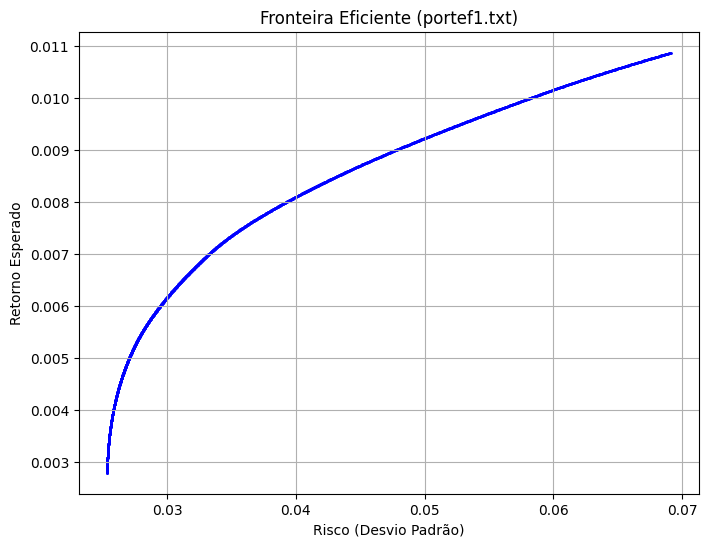

In [82]:
# Carrega os dados da fronteira eficiente
file_path = 'portef1.txt'
df_portef = pd.read_csv(file_path, sep="\s+", header=None, names=["mean_return", "variance"])
df_portef["std_dev"] = np.sqrt(df_portef["variance"])  # Calcula risco (desvio padrão)

# Plota com pontos individuais
plt.figure(figsize=(8, 6))
plt.scatter(df_portef["std_dev"], df_portef["mean_return"], s=1, color='blue')  # s=10 reduz o tamanho dos pontos
plt.title("Fronteira Eficiente (portef1.txt)")
plt.xlabel("Risco (Desvio Padrão)")
plt.ylabel("Retorno Esperado")
plt.grid(True)
plt.show()


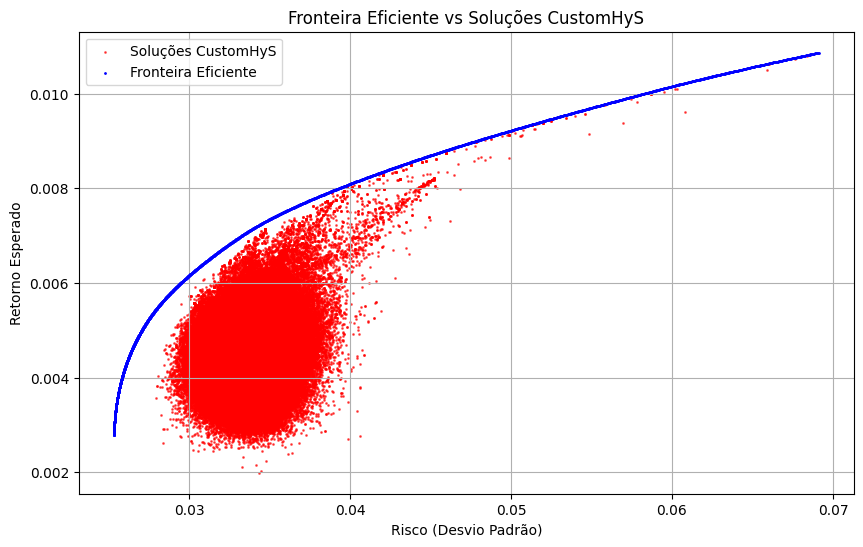

In [83]:
# 🔹 Gráfico: soluções vs fronteira eficiente
plt.figure(figsize=(10, 6))
plt.scatter(df_logs["risk"], df_logs["expected_return"], s=1, color='red', alpha=0.6, label="Soluções CustomHyS")
plt.scatter(df_portef["std_dev"], df_portef["mean_return"], s=1, color='blue', label="Fronteira Eficiente", zorder=5)  # zorder=5 para ficar na frente
plt.title("Fronteira Eficiente vs Soluções CustomHyS")
plt.xlabel("Risco (Desvio Padrão)")
plt.ylabel("Retorno Esperado")
plt.grid(True)
plt.legend(loc="upper left")
plt.show()

In [51]:
from scipy.interpolate import interp1d

# 🔹 Funções de interpolação
interp_return = interp1d(df_portef["std_dev"], df_portef["mean_return"], kind='linear', bounds_error=False, fill_value="extrapolate")
interp_risk = interp1d(df_portef["mean_return"], df_portef["std_dev"], kind='linear', bounds_error=False, fill_value="extrapolate")

# 🔹 Cálculo dos erros
df_logs["interp_ret_from_risk"] = interp_return(df_logs["risk"])
df_logs["interp_risk_from_ret"] = interp_risk(df_logs["expected_return"])
df_logs["error_return"] = np.abs(df_logs["expected_return"] - df_logs["interp_ret_from_risk"]) / df_logs["interp_ret_from_risk"]
df_logs["error_risk"] = np.abs(df_logs["risk"] - df_logs["interp_risk_from_ret"]) / df_logs["interp_risk_from_ret"]
df_logs["percent_error"] = df_logs[["error_return", "error_risk"]].min(axis=1)

# 🔹 Estatísticas
print(f"📉 Erro percentual médio: {df_logs['percent_error'].mean():.4f}")
print(f"📈 Erro percentual mediano: {df_logs['percent_error'].median():.4f}")

print("\n🚨 Top 5 maiores erros percentuais:")
display(df_logs.sort_values(by="percent_error", ascending=False).head(5)[[
    "expected_return", "risk", "interp_ret_from_risk", "interp_risk_from_ret", "percent_error"
]])

📉 Erro percentual médio: 0.2739
📈 Erro percentual mediano: 0.2910

🚨 Top 5 maiores erros percentuais:


,expected_return,risk,interp_ret_from_risk,interp_risk_from_ret,percent_error
4017,0.000392,0.050467,0.009267,0.025338,0.957699
212837,0.000436,0.050109,0.009231,0.025338,0.952768
226141,0.000446,0.050134,0.009234,0.025338,0.951673
2249,0.000487,0.049379,0.009158,0.025338,0.946828
17658,0.000541,0.049988,0.009219,0.025338,0.941338


In [52]:
import matplotlib.pyplot as plt
# 🔹 Seleciona destaques
melhor_sharpe = df_logs.loc[df_logs["sharpe"].idxmax()]
maior_retorno = df_logs.loc[df_logs["expected_return"].idxmax()]
menor_risco = df_logs.loc[df_logs["risk"].idxmin()]
primeiro = df_logs.iloc[0]  # Primeira solução
ultima = df_logs.iloc[-1]  # Última solução

# 🔹 Exibe os detalhes
def print_destaque(titulo, solucao):
    print(f"\n{titulo}")
    print(f"Sharpe: {solucao['sharpe']}")
    print(f"Retorno Esperado: {solucao['expected_return']}")
    print(f"Risco (Desvio Padrão): {solucao['risk']}")
    print(f"Erro Percentual (interp): {solucao['percent_error']:.4f}")
    print(f"Ações Selecionadas: {solucao['selected_assets']}")
    print(f"Pesos: {solucao['weights']}")

print_destaque("🏅 Melhor solução (Sharpe)", melhor_sharpe)
print_destaque("📈 Maior retorno", maior_retorno)
print_destaque("🛡️ Menor risco", menor_risco)
print_destaque("⏳ Primeira solução", primeiro)
print_destaque("⏳ Última solução", ultima)



🏅 Melhor solução (Sharpe)
Sharpe: 0.07848740670403234
Retorno Esperado: 0.075759
Risco (Desvio Padrão): 0.5830107264538925
Erro Percentual (interp): 0.3995
Ações Selecionadas: [2, 4, 5, 7, 8, 9, 11, 12, 18, 19, 21, 22, 23, 25, 26, 27, 28]
Pesos: [0. 0. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1.
 0. 1. 1. 1. 1. 0. 0.]

📈 Maior retorno
Sharpe: 0.060364831916814465
Retorno Esperado: 0.084681
Risco (Desvio Padrão): 0.9058419987875218
Erro Percentual (interp): 0.1727
Ações Selecionadas: [1, 2, 3, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30]
Pesos: [0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 1. 1.]

🛡️ Menor risco
Sharpe: -1000000.0
Retorno Esperado: 0.0
Risco (Desvio Padrão): 0.0
Erro Percentual (interp): -1.0000
Ações Selecionadas: []
Pesos: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0.]

⏳ Primeira solução
Sharpe: -0.806318989

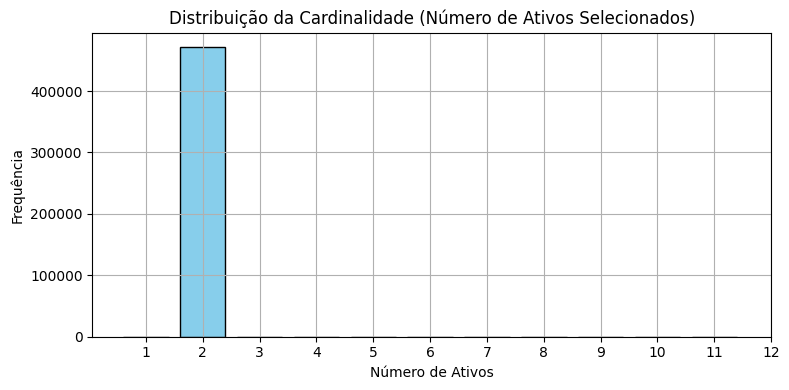

In [16]:
# Contagem de ativos por solução
df_logs["num_selected"] = df_logs["selected_assets"].apply(len)
# Histograma do número de ativos selecionados por solução
plt.figure(figsize=(8, 4))
plt.hist(df_logs["num_selected"], bins=range(1, 13), align='left', rwidth=0.8, color='skyblue', edgecolor='black')
plt.title("Distribuição da Cardinalidade (Número de Ativos Selecionados)")
plt.xlabel("Número de Ativos")
plt.ylabel("Frequência")
plt.grid(True)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

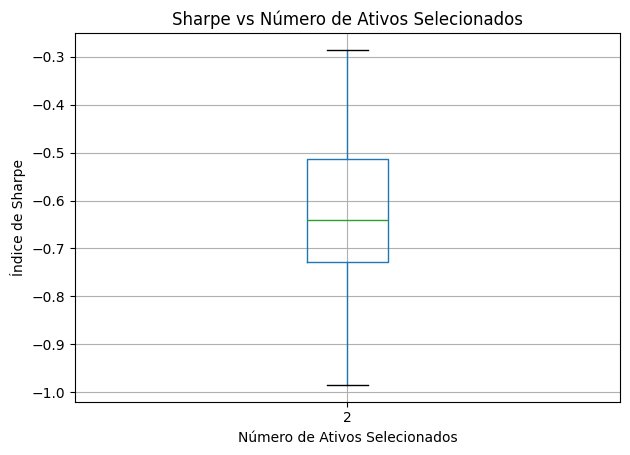

In [ ]:
# Configuração da instância com as novas restrições
instance_data = from_port1

# Parâmetros para o problema
cardinality_k = 3  # Máximo de 3 ativos no portfólio
decimal_precision = 3  # 3 casas decimais

# Configuração do problema com novas restrições
problem_config = configure_problem(
    instance_data=instance_data, 
    cardinality_constraint=cardinality_k,
    decimal_places=decimal_precision,
    risk_free_rate=0.03
)

print("🔧 Configuração do problema:")
print(f"  - Número de ativos: {instance_data['n_assets']}")
print(f"  - Restrição de cardinalidade: {cardinality_k} ativos")
print(f"  - Casas decimais: {decimal_precision}")
print(f"  - Soma dos pesos: 1.0 (automática)")
print(f"  - Chaves do problema: {list(problem_config.keys())}")

# Criação e execução da hyper-heurística
from customhys.hyperheuristic import Hyperheuristic

hh = Hyperheuristic(heuristic_space='default.txt', problem=problem_config, parameters=hh_config)

print("\n🚀 Executando hiper-heurística com novas restrições...")
result = hh.solve()

print("✅ Execução concluída!")
print(f"Melhor solução encontrada: {result}")

# Análise da melhor solução
if execution_logs:
    best_solution = min(execution_logs, key=lambda x: x.get('objective', float('inf')))
    weights = np.array(best_solution['weights'])
    
    print(f"\n📊 Análise da melhor solução:")
    print(f"  - Função objetivo: {best_solution['objective']:.6f}")
    print(f"  - Retorno esperado: {best_solution['expected_return']:.4f}")
    print(f"  - Risco (desvio padrão): {best_solution['risk']:.4f}")
    print(f"  - Índice de Sharpe: {best_solution['sharpe']:.4f}")
    print(f"  - Ativos selecionados: {best_solution['selected_assets']}")
    print(f"  - Número de ativos ativos: {len(best_solution['selected_assets'])}")
    print(f"  - Soma dos pesos: {sum(weights):.6f}")
    print(f"  - Pesos do portfólio: {weights}")
    
    # Verificação das restrições
    non_zero_assets = np.sum(weights > 1e-6)
    print(f"\n✅ Verificação das restrições:")
    print(f"  - Cardinalidade respeitada: {non_zero_assets <= cardinality_k} ({non_zero_assets} <= {cardinality_k})")
    print(f"  - Soma = 1.0: {abs(sum(weights) - 1.0) < 1e-6} (diferença: {abs(sum(weights) - 1.0):.8f})")
    print(f"  - Casas decimais: {all(len(str(w).split('.')[-1]) <= decimal_precision for w in weights if w > 0)}")
else:
    print("⚠️ Nenhum log de execução encontrado")

In [1]:
# Scatterplot 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_logs["risk"], df_logs["expected_return"], df_logs["sharpe"], c=df_logs["sharpe"], cmap='coolwarm')
ax.set_xlabel("Risco")
ax.set_ylabel("Retorno Esperado")
ax.set_zlabel("Sharpe")
ax.set_title("Distribuição 3D: Risco vs Retorno vs Sharpe")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

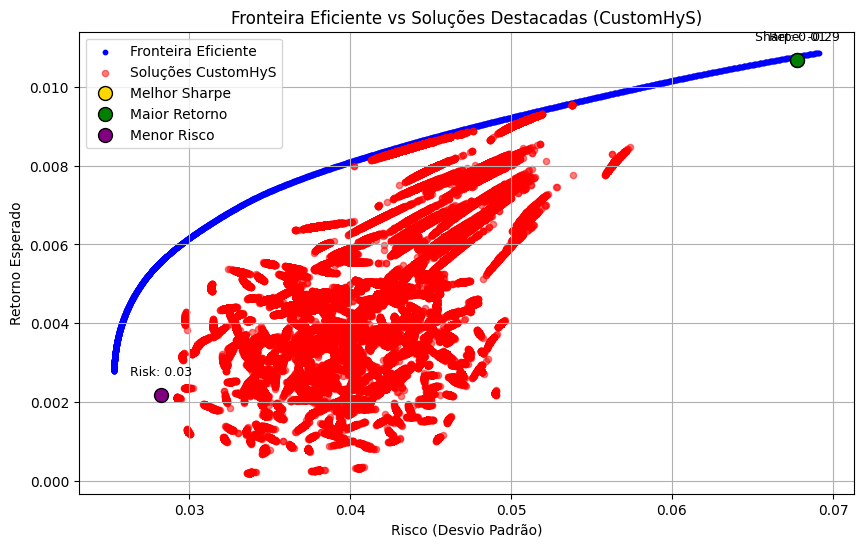

In [18]:
plt.figure(figsize=(10, 6))

# Fronteira e todas as soluções
plt.scatter(df_portef["std_dev"], df_portef["mean_return"], s=10, color='blue', label="Fronteira Eficiente")
plt.scatter(df_logs["risk"], df_logs["expected_return"], s=20, color='red', alpha=0.5, label="Soluções CustomHyS")

# Destaques
plt.scatter(melhor_sharpe["risk"], melhor_sharpe["expected_return"], s=100, color='gold', edgecolor='black', label="Melhor Sharpe", zorder=5)
plt.scatter(maior_retorno["risk"], maior_retorno["expected_return"], s=100, color='green', edgecolor='black', label="Maior Retorno", zorder=5)
plt.scatter(menor_risco["risk"], menor_risco["expected_return"], s=100, color='purple', edgecolor='black', label="Menor Risco", zorder=5)

# Rótulos
plt.text(melhor_sharpe["risk"], melhor_sharpe["expected_return"] + 0.0005, f"Sharpe: {melhor_sharpe['sharpe']:.2f}", ha='center', fontsize=9)
plt.text(maior_retorno["risk"], maior_retorno["expected_return"] + 0.0005, f"Ret: {maior_retorno['expected_return']:.2f}", ha='center', fontsize=9)
plt.text(menor_risco["risk"], menor_risco["expected_return"] + 0.0005, f"Risk: {menor_risco['risk']:.2f}", ha='center', fontsize=9)

plt.title("Fronteira Eficiente vs Soluções Destacadas (CustomHyS)")
plt.xlabel("Risco (Desvio Padrão)")
plt.ylabel("Retorno Esperado")
plt.grid(True)
plt.legend()
plt.show()

